In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader 

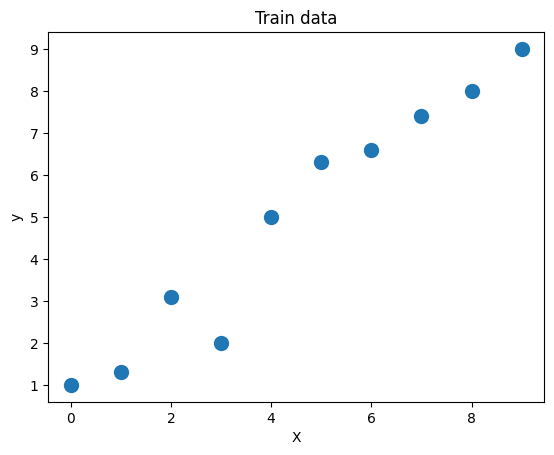

In [2]:
X_train = np.arange(10, dtype='float32').reshape((10, 1))
y_train = np.array([1., 1.3, 3.1, 2.0, 5.0, 6.3, 6.6, 7.4, 8.0, 9.0], dtype='float32')
plt.plot(X_train, y_train, marker='o', markersize=10, linestyle='')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Train data')
plt.show()

In [3]:
X_train_norm = (X_train - X_train.mean()) / X_train.std()
X_train_norm = torch.from_numpy(X_train_norm)
y_train = torch.from_numpy(y_train)
dataset_tr = TensorDataset(X_train_norm, y_train)
train_DL = DataLoader(dataset=dataset_tr, shuffle=True, batch_size=1)

In [16]:
torch.manual_seed(42)
w = torch.rand(1, dtype=torch.float32)
w.requires_grad_()
b = torch.zeros(1, requires_grad=True)
def model(x):
    return x @ w + b

In [35]:
def loss_fn(y_true, y_pred):
    return torch.mean((y_pred - y_true).pow(2))

In [36]:
learning_rate = 0.001
epoches = 200
log_epoche = 20
for epoche in range(1, epoches+1):   
    for x, y in train_DL:
        y_pred = model(x)
        loss = loss_fn(y, y_pred)
        loss.backward()

    with torch.no_grad():
        w -= w.grad * learning_rate
        b -= b.grad * learning_rate
        w.grad.zero_()
        b.grad.zero_()
    
    if epoche % log_epoche == 0:
        print(f'epoche: {epoche}, loss: {loss.item():.4f}')

epoche: 20, loss: 0.0997
epoche: 40, loss: 0.0472
epoche: 60, loss: 0.3096
epoche: 80, loss: 0.9465
epoche: 100, loss: 0.9465
epoche: 120, loss: 2.1651
epoche: 140, loss: 0.0015
epoche: 160, loss: 2.1651
epoche: 180, loss: 0.1190
epoche: 200, loss: 0.0997


In [37]:
print(f'w = {w.item():.4f}')
print(f'b = {b.item():.4f}')

w = 2.6748
b = 4.8826


torch.float32


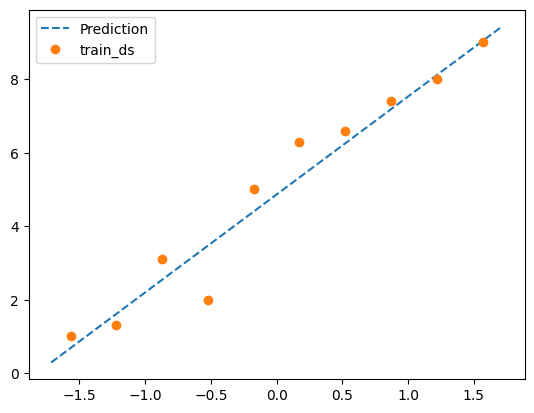

In [38]:
X_test = np.linspace(0, 9, 100, dtype = 'float32').reshape(100, 1)
X_test_norm = (X_test - X_test.mean()) / X_test.std()
X_test_norm = torch.from_numpy(X_test_norm)
print(X_test_norm.dtype)
y_pred = model(X_test_norm).detach().numpy()
plt.plot(X_test_norm, y_pred, linestyle="--", label='Prediction')
plt.plot(X_train_norm, y_train, marker='o', label='train_ds', linestyle='')
plt.legend()
plt.show()

In [23]:
loss_fn = torch.nn.MSELoss(reduction='mean')
input_size = 1
output_size = 1
model = torch.nn.Linear(in_features=input_size, out_features=output_size)

In [24]:
model._parameters

{'weight': Parameter containing:
 tensor([[0.3972]], requires_grad=True),
 'bias': Parameter containing:
 tensor([-0.8929], requires_grad=True)}

In [25]:
model.parameters()

<generator object Module.parameters at 0x0000021EF6BBC4A0>

In [26]:
learning_rate = 0.001
optimezer = torch.optim.SGD(params=model.parameters(), lr=learning_rate)

In [27]:
epoches = 200
log_epoches = 20
for epoche in range(epoches):
    for x_batch, y_batch in train_DL:
        y_pred = model(x_batch)[:, 0]
        loss = loss_fn(y_batch, y_pred)
        loss.backward()
        optimezer.step()
        optimezer.zero_grad()
    if epoche % log_epoches == 0:
        print(f'epoche {epoche}, loss: {loss.item():.4f}')

epoche 0, loss: 18.2962
epoche 20, loss: 2.2652
epoche 40, loss: 12.5862
epoche 60, loss: 0.2808
epoche 80, loss: 2.6644
epoche 100, loss: 1.5017
epoche 120, loss: 0.2243
epoche 140, loss: 1.6468
epoche 160, loss: 0.1503
epoche 180, loss: 0.1111


In [34]:
print(f'weight = {model.weight.item():.4f}')
print(f'bias = {model.bias.item():.4f}')

weight = 2.6650
bias = 4.8632
